# Temporal Horizon Detection — Activation Extraction + Linear Probing

Combined notebook: Part 1 (Week 1) extracts residual-stream activations, Part 2 (Week 2)
trains linear probes to locate the temporal subspace.

In-memory handoff eliminates the risk of loading stale `.pt` files between runs.
All outputs still saved to Google Drive for downstream use (Week 3 steering).

# Setup

In [8]:
%%bash
git clone https://github.com/Avi161/temporal-awareness.git
cd temporal-awareness
git checkout research/rq1-week1-extraction
pip install -e '.[dev]' -q

Branch 'research/rq1-week1-extraction' set up to track remote branch 'research/rq1-week1-extraction' from 'origin'.


Cloning into 'temporal-awareness'...
Switched to a new branch 'research/rq1-week1-extraction'


In [9]:
# ── Google Drive persistence ────────────────────────────────────────────────────────────
# Saves out/ to Drive so Week 3 notebook can load outputs without re-running.
import os
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DRIVE_OUT = Path("/content/drive/MyDrive/temporal-awareness-out")
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

LOCAL_OUT = Path("/content/temporal-awareness/out")
if LOCAL_OUT.is_symlink() or LOCAL_OUT.exists():
    LOCAL_OUT.unlink() if LOCAL_OUT.is_symlink() else None
if not LOCAL_OUT.exists():
    LOCAL_OUT.symlink_to(DRIVE_OUT)

print(f"out/ → {DRIVE_OUT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
out/ → /content/drive/MyDrive/temporal-awareness-out


In [10]:
import os
import sys

os.chdir('/content/temporal-awareness')
sys.path.insert(0, '/content/temporal-awareness')

import json
import pickle
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from src.inference import ModelRunner
from src.inference.backends import ModelBackend
from src.intertemporal.common.project_paths import get_experiment_dir
from scripts.week1.activation_extractor import (
    load_implicit_dataset,
    build_prompts,
    extract_activations_for_prompts,
    save_extraction_results,
)

In [ ]:
from huggingface_hub import login

# Paste your HF token below — DO NOT commit this cell with the token filled in
login(token="YOUR_HF_TOKEN")

In [12]:
# Primary model — 16 GB VRAM recommended
# Note: TransformerLens uses "Llama-3.1-8B" (no "Meta-" prefix)
MODEL_NAME = "meta-llama/Llama-3.1-8B"
# MODEL_NAME = "mistralai/Mistral-7B-v0.1"  # fallback if VRAM constrained

DATASET_PATH = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json")
OUT_DIR = get_experiment_dir() / "week1_activation_extraction"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [13]:
runner = ModelRunner(
    MODEL_NAME,
    backend=ModelBackend.TRANSFORMERLENS,
    dtype=torch.float16,
)
print(f"n_layers = {runner.n_layers}")
print(f"d_model  = {runner.d_model}")

Loading meta-llama/Llama-3.1-8B on cuda (TransformerLens)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer
Model loaded: ModelBackend.TRANSFORMERLENS meta-llama/Llama-3.1-8B (chat=False)
  n_layers=32, d_model=4096

n_layers = 32
d_model  = 4096


─── # Part 1: Activation Extraction (Week 1) ───

## Section 1 — Explicit Dataset (500 pairs)

In [18]:
pairs, metadata = load_implicit_dataset(DATASET_PATH)
print(f"\nLoaded {len(pairs)} pairs")
print("\nFirst pair:")
for p in pairs[:1]:
    print(p)


Loaded 500 pairs

First pair:
{'id': 1, 'category': 'planning', 'question': 'When developing a roadmap for this initiative, consider:', 'immediate': ' (A) What we can deliver in the next 30 days', 'long_term': ' (B) What position we want in 10 years'}


In [19]:
all_names = runner.get_all_names_for_internals()
resid_names = [n for n in all_names if "hook_resid_post" in n]
print(f"Found {len(resid_names)} hook_resid_post layers")
print("First 3:", resid_names[:3])
print("Last 3: ", resid_names[-3:])

Found 32 hook_resid_post layers
First 3: ['blocks.0.hook_resid_post', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_post']
Last 3:  ['blocks.29.hook_resid_post', 'blocks.30.hook_resid_post', 'blocks.31.hook_resid_post']


In [25]:
immediate_prompts = [p["question"] + p["immediate"] for p in pairs]
long_term_prompts  = [p["question"] + p["long_term"]  for p in pairs]
categories         = [p["category"] for p in pairs]
print(f"immediate_prompts[0]: {immediate_prompts[0]!r}")
print(f"long_term_prompts[0]:  {long_term_prompts[0]!r}")
print(f"categories[0]:         {categories[0]!r}")

immediate_prompts[0]: 'When developing a roadmap for this initiative, consider: (A) What we can deliver in the next 30 days'
long_term_prompts[0]:  'When developing a roadmap for this initiative, consider: (B) What position we want in 10 years'
categories[0]:         'planning'


In [21]:
test_prompt = immediate_prompts[0]
logits, cache = runner.run_with_cache(
    test_prompt,
    names_filter=lambda n: "hook_resid_post" in n,
)
sample_act = cache["blocks.0.hook_resid_post"][0, -1, :]
print(f"Logits shape:           {logits.shape}")
print(f"Sample activation shape: {sample_act.shape}  (d_model={runner.d_model})")
assert sample_act.shape[0] == runner.d_model, "d_model mismatch"
assert torch.isfinite(sample_act).all(), "Non-finite values in sample activation"
print("Sanity check passed.")

Logits shape:           torch.Size([1, 23, 128256])
Sample activation shape: torch.Size([4096])  (d_model=4096)
Sanity check passed.


In [22]:
acts_immediate = extract_activations_for_prompts(runner, immediate_prompts, desc="Immediate")
print(f"Shape: {acts_immediate.shape}")  # expected [500, n_layers, d_model]

Immediate: 100%|██████████| 500/500 [00:41<00:00, 12.01it/s]

Shape: torch.Size([500, 32, 4096])


In [23]:
acts_long_term = extract_activations_for_prompts(runner, long_term_prompts, desc="Long-term")
print(f"Shape: {acts_long_term.shape}")  # expected [500, n_layers, d_model]

Long-term: 100%|██████████| 500/500 [00:41<00:00, 12.03it/s]

Shape: torch.Size([500, 32, 4096])


In [26]:
save_extraction_results(
    OUT_DIR,
    acts_immediate,
    acts_long_term,
    categories,
    pairs,
    MODEL_NAME,
    DATASET_PATH,
)
print(f"Saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s}  {size_mb:.1f} MB")

Saved to: /content/temporal-awareness/out/experiments/week1_activation_extraction
  activations_immediate.pt                  131.1 MB
  activations_long_term.pt                  131.1 MB
  metadata.json                             0.0 MB
  pair_metadata.json                        0.0 MB


In [27]:
# Freshness check — confirm files were just written
for fname in ["activations_immediate.pt", "activations_long_term.pt"]:
    fpath = OUT_DIR / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

activations_immediate.pt last modified: 1773939005
activations_long_term.pt last modified: 1773939006


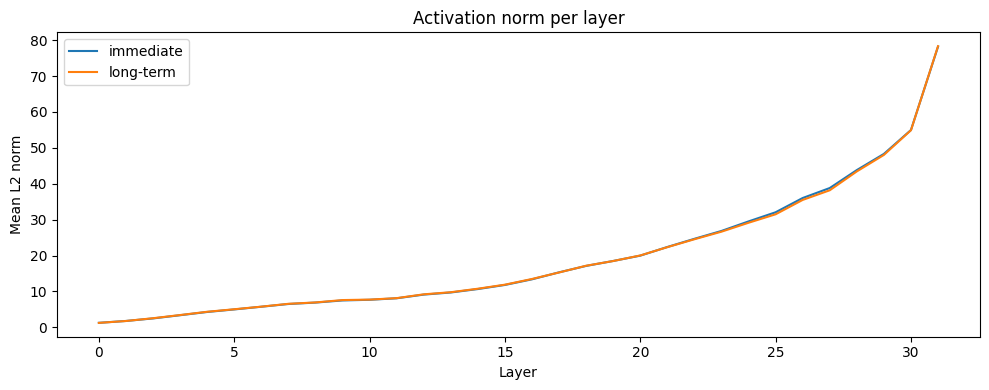

All values finite: OK


In [28]:
# Verification: per-layer L2 norm distribution — should be smooth
norms_imm = acts_immediate.norm(dim=-1).mean(dim=0).cpu()  # [n_layers]
norms_lt  = acts_long_term.norm(dim=-1).mean(dim=0).cpu()

plt.figure(figsize=(10, 4))
plt.plot(norms_imm, label="immediate")
plt.plot(norms_lt,  label="long-term")
plt.xlabel("Layer")
plt.ylabel("Mean L2 norm")
plt.legend()
plt.title("Activation norm per layer")
plt.tight_layout()
plt.show()

# Verify finite values
assert torch.isfinite(acts_immediate).all(), "Non-finite values in acts_immediate"
assert torch.isfinite(acts_long_term).all(), "Non-finite values in acts_long_term"
print("All values finite: OK")

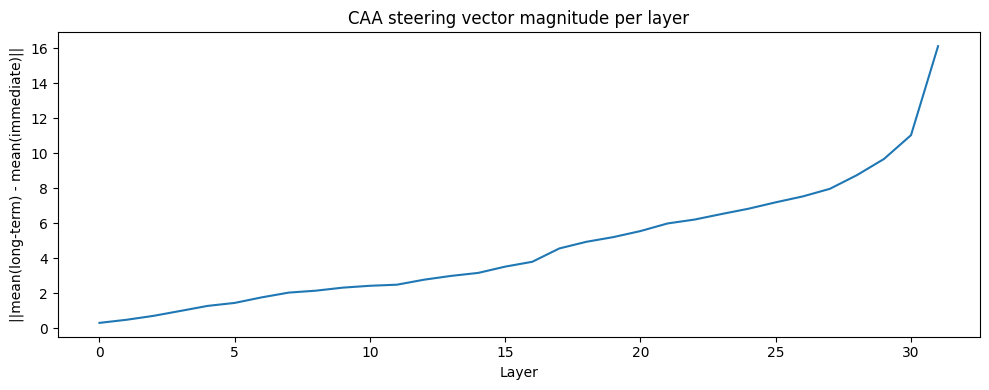

Peak CAA magnitude at layer 31 (of 32)


In [29]:
# Steering vector preview: mean activation difference per layer
# Norm should peak in middle-to-late layers (consistent with interpretability literature)
diff = (acts_long_term - acts_immediate).mean(dim=0)  # [n_layers, d_model]
diff_norms = diff.norm(dim=-1).cpu()

plt.figure(figsize=(10, 4))
plt.plot(diff_norms)
plt.xlabel("Layer")
plt.ylabel("||mean(long-term) - mean(immediate)||")
plt.title("CAA steering vector magnitude per layer")
plt.tight_layout()
plt.show()

peak_layer = diff_norms.argmax().item()
print(f"Peak CAA magnitude at layer {peak_layer} (of {runner.n_layers})")

## Section 2 — Implicit Dataset (300 pairs)

The explicit dataset above uses surface temporal keywords ("next 30 days", "10 years").
Here we repeat the extraction on the **implicit** dataset (300 pairs, no temporal keywords)
and compare side-by-side to see whether the temporal signal is surface-level or semantic.

In [30]:
IMPLICIT_DATASET_PATH = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json")
IMPLICIT_OUT_DIR = get_experiment_dir() / "week1_activation_extraction_implicit"
IMPLICIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

pairs_implicit, metadata_implicit = load_implicit_dataset(IMPLICIT_DATASET_PATH)
print(f"\nLoaded {len(pairs_implicit)} pairs")
print("\nFirst pair:")
for p in pairs_implicit[:1]:
    print(p)


Loaded 300 pairs

First pair:
{'id': 1, 'question': 'When the system fails, the first priority becomes', 'immediate': ' (A) containing the spreading damage before it escalates', 'long_term': ' (B) redesigning the architecture to prevent recurrence', 'category': 'crisis_vs_foundation'}


In [34]:
immediate_prompts_impl = [p["question"] + p["immediate"] for p in pairs_implicit]
long_term_prompts_impl  = [p["question"] + p["long_term"]  for p in pairs_implicit]
categories_impl         = [p["category"] for p in pairs_implicit]
print(f"immediate_prompts_impl[0]: {immediate_prompts_impl[0]!r}")
print(f"long_term_prompts_impl[0]:  {long_term_prompts_impl[0]!r}")
print(f"categories_impl[0]:         {categories_impl[0]!r}")
print(f"immediate_prompts_impl[1]: {immediate_prompts_impl[1]!r}")
print(f"long_term_prompts_impl[1]:  {long_term_prompts_impl[1]!r}")
print(f"categories_impl[1]:         {categories_impl[1]!r}")

immediate_prompts_impl[0]: 'When the system fails, the first priority becomes (A) containing the spreading damage before it escalates'
long_term_prompts_impl[0]:  'When the system fails, the first priority becomes (B) redesigning the architecture to prevent recurrence'
categories_impl[0]:         'crisis_vs_foundation'
immediate_prompts_impl[1]: 'The hospital administrator directs resources toward (B) stabilizing patients in critical condition'
long_term_prompts_impl[1]:  'The hospital administrator directs resources toward (A) training staff and upgrading medical equipment'
categories_impl[1]:         'crisis_vs_foundation'


In [33]:
acts_immediate_impl = extract_activations_for_prompts(runner, immediate_prompts_impl, desc="Implicit Immediate")
acts_long_term_impl = extract_activations_for_prompts(runner, long_term_prompts_impl, desc="Implicit Long-term")
print(f"Implicit immediate shape: {acts_immediate_impl.shape}")
print(f"Implicit long-term shape: {acts_long_term_impl.shape}")

assert torch.isfinite(acts_immediate_impl).all(), "Non-finite values in implicit immediate"
assert torch.isfinite(acts_long_term_impl).all(), "Non-finite values in implicit long-term"
print("All values finite: OK")

Implicit Long-term: 100%|██████████| 300/300 [00:25<00:00, 11.98it/s]


Implicit immediate shape: torch.Size([300, 32, 4096])
Implicit long-term shape: torch.Size([300, 32, 4096])
All values finite: OK


In [35]:
save_extraction_results(
    IMPLICIT_OUT_DIR,
    acts_immediate_impl,
    acts_long_term_impl,
    categories_impl,
    pairs_implicit,
    MODEL_NAME,
    IMPLICIT_DATASET_PATH,
)
print(f"Saved to: {IMPLICIT_OUT_DIR}")
for f in sorted(IMPLICIT_OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s}  {size_mb:.1f} MB")

Saved to: /content/temporal-awareness/out/experiments/week1_activation_extraction_implicit
  activations_immediate.pt                  78.6 MB
  activations_long_term.pt                  78.6 MB
  metadata.json                             0.0 MB
  pair_metadata.json                        0.0 MB


In [36]:
# Freshness check — confirm files were just written
for fname in ["activations_immediate.pt", "activations_long_term.pt"]:
    fpath = IMPLICIT_OUT_DIR / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

activations_immediate.pt last modified: 1773939135
activations_long_term.pt last modified: 1773939136


## Section 3 — Side-by-Side Comparison

**Plot 1** — Activation norm per layer: do both datasets show the same growth pattern?
**Plot 2** — CAA vector magnitude per layer: does the peak shift when temporal keywords are absent?
**Plot 3** — Cosine similarity between the two CAA vectors at each layer: are the directions the same?

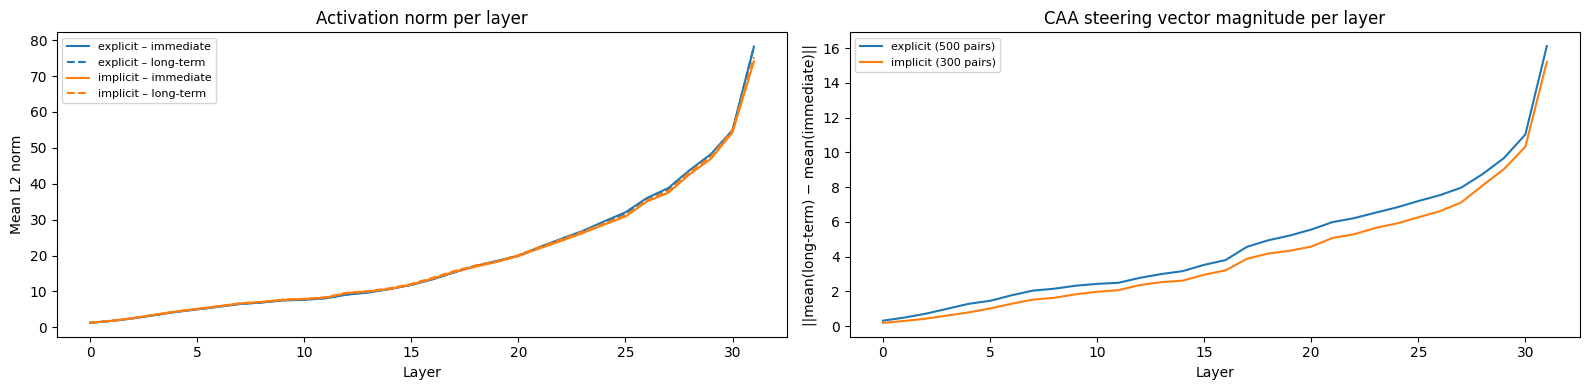

Explicit peak CAA layer: 31  (of 32)
Implicit peak CAA layer: 31  (of 32)


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- Plot 1: Activation norm per layer ---
ax = axes[0]
norms_imm_expl = acts_immediate.norm(dim=-1).mean(dim=0).cpu()
norms_lt_expl  = acts_long_term.norm(dim=-1).mean(dim=0).cpu()
norms_imm_impl = acts_immediate_impl.norm(dim=-1).mean(dim=0).cpu()
norms_lt_impl  = acts_long_term_impl.norm(dim=-1).mean(dim=0).cpu()

ax.plot(norms_imm_expl, label="explicit – immediate",  color="tab:blue",   linestyle="-")
ax.plot(norms_lt_expl,  label="explicit – long-term",  color="tab:blue",   linestyle="--")
ax.plot(norms_imm_impl, label="implicit – immediate",  color="tab:orange",  linestyle="-")
ax.plot(norms_lt_impl,  label="implicit – long-term",  color="tab:orange",  linestyle="--")
ax.set_xlabel("Layer")
ax.set_ylabel("Mean L2 norm")
ax.set_title("Activation norm per layer")
ax.legend(fontsize=8)

# --- Plot 2: CAA vector magnitude per layer ---
ax = axes[1]
diff_expl = (acts_long_term - acts_immediate).mean(dim=0)          # [n_layers, d_model]
diff_impl = (acts_long_term_impl - acts_immediate_impl).mean(dim=0)
diff_norms_expl = diff_expl.norm(dim=-1).cpu()
diff_norms_impl = diff_impl.norm(dim=-1).cpu()

ax.plot(diff_norms_expl, label="explicit (500 pairs)", color="tab:blue")
ax.plot(diff_norms_impl, label="implicit (300 pairs)", color="tab:orange")
ax.set_xlabel("Layer")
ax.set_ylabel("||mean(long-term) − mean(immediate)||")
ax.set_title("CAA steering vector magnitude per layer")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

peak_expl = diff_norms_expl.argmax().item()
peak_impl = diff_norms_impl.argmax().item()
print(f"Explicit peak CAA layer: {peak_expl}  (of {runner.n_layers})")
print(f"Implicit peak CAA layer: {peak_impl}  (of {runner.n_layers})")

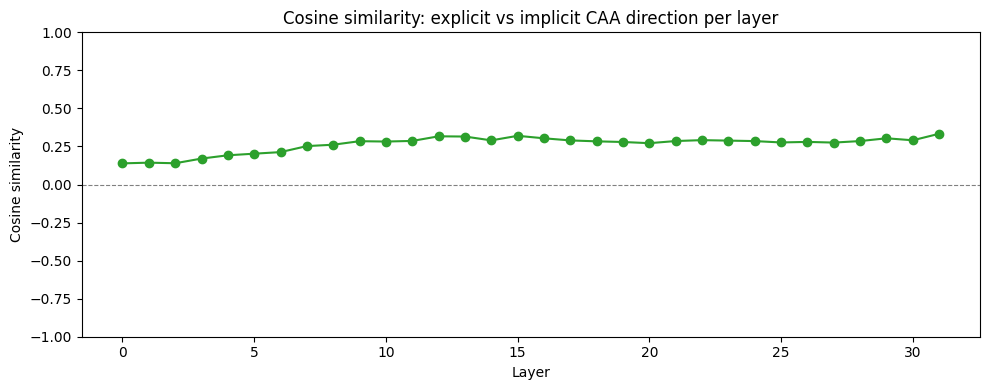

Mean cosine similarity (all layers): 0.264
Max  cosine similarity: 0.334  at layer 31
Min  cosine similarity: 0.139  at layer 0

Interpretation:
  ~1.0  → same temporal direction (semantic, keyword-independent)
  ~0.0  → unrelated directions (explicit driven by surface tokens)
  ~-1.0 → opposite directions (pathological / very different datasets)


In [38]:
# Cosine similarity between the two CAA directions at each layer
# High similarity → the model encodes the same temporal direction regardless of keywords
# Low similarity → explicit keywords drive a different (possibly surface-level) direction

cosine_sims = torch.nn.functional.cosine_similarity(
    diff_expl.float(), diff_impl.float(), dim=-1
).cpu()  # [n_layers]

plt.figure(figsize=(10, 4))
plt.plot(cosine_sims, marker="o", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Layer")
plt.ylabel("Cosine similarity")
plt.title("Cosine similarity: explicit vs implicit CAA direction per layer")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

print(f"Mean cosine similarity (all layers): {cosine_sims.mean():.3f}")
print(f"Max  cosine similarity: {cosine_sims.max():.3f}  at layer {cosine_sims.argmax().item()}")
print(f"Min  cosine similarity: {cosine_sims.min():.3f}  at layer {cosine_sims.argmin().item()}")
print()
print("Interpretation:")
print("  ~1.0  → same temporal direction (semantic, keyword-independent)")
print("  ~0.0  → unrelated directions (explicit driven by surface tokens)")
print("  ~-1.0 → opposite directions (pathological / very different datasets)")

─── # Part 2: Linear Probing (Week 2) ───

**Why we're doing this:**
Week 1 showed the explicit-dataset CAA vector peaks at Layer 31 — a red flag.
Late layers in transformers typically handle surface token-prediction adjustments,
not abstract semantic content. The cosine similarity between explicit and implicit
CAA directions was only ~0.34, suggesting explicit dataset vectors are contaminated
by surface time-word heuristics.

**Approach (Geometry of Truth methodology):**
- Train a logistic regression probe per layer on the *implicit* dataset
- The layer with the highest test accuracy is where temporal content is encoded semantically
- Zero-shot evaluate those probes on the *explicit* dataset to test generalization
- Redefine the CAA steering vector from implicit dataset means at the best-probe layer

Activations are passed **in-memory** from Part 1 — no stale `.pt` file risk.

## Probing Setup

Configuration for Part 2. Activations are already in memory from Part 1:
- `acts_immediate_impl` / `acts_long_term_impl` — implicit (300 pairs)
- `acts_immediate` / `acts_long_term` — explicit (500 pairs)

In [39]:
OUT_DIR_PROBING = get_experiment_dir() / "week2_probing"
OUT_DIR_PROBING.mkdir(parents=True, exist_ok=True)

# In-memory handoff from Part 1 (no torch.load needed)
n_impl = acts_immediate_impl.shape[0]
n_expl = acts_immediate.shape[0]

N_LAYERS = 32
RANDOM_STATE = 42

print(f"Implicit activations: {acts_immediate_impl.shape} (n={n_impl})")
print(f"Explicit activations: {acts_immediate.shape} (n={n_expl})")
print("Ready for probing.")

Implicit activations: torch.Size([300, 32, 4096]) (n=300)
Explicit activations: torch.Size([500, 32, 4096]) (n=500)
Ready for probing.


## Section 4 — Per-Layer Linear Probing on Implicit Data

For each of the 32 layers:
- Stack immediate (label=0) and long-term (label=1) activations → [600, 4096]
- 80/20 stratified train/test split (random_state=42 for reproducibility)
- Fit LogisticRegression(C=0.1, max_iter=1000) — light L2 regularization per GoT paper
- Record test accuracy and save the trained probe to disk

**Why C=0.1?** The Geometry of Truth paper uses moderate regularization to prevent
overfitting and ensure the probe direction reflects a clean linear feature, not
dataset-specific noise.

In [40]:
# Build numpy arrays: X [n_impl*2, d_model] per layer, y [n_impl*2]
# Convert float16 → float32 for sklearn
X_impl_np = torch.cat([acts_immediate_impl, acts_long_term_impl], dim=0).float().numpy()
# X_impl_np shape: [600, 32, 4096] — index as [sample, layer, d_model]
y_impl = np.array([0]*n_impl + [1]*n_impl)  # 0=immediate, 1=long_term

layer_results = []

for layer in tqdm(range(N_LAYERS), desc="Probing layers"):
    X_layer = X_impl_np[:, layer, :]   # [600, 4096]

    X_train, X_test, y_train, y_test = train_test_split(
        X_layer, y_impl,
        test_size=0.2, random_state=RANDOM_STATE, stratify=y_impl
    )

    probe = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)
    probe.fit(X_train, y_train)
    test_acc = probe.score(X_test, y_test)

    # Save probe to disk
    with open(OUT_DIR_PROBING / f"probe_layer_{layer:02d}.pkl", "wb") as f:
        pickle.dump(probe, f)

    layer_results.append({
        "layer": layer,
        "test_accuracy": test_acc,
        "n_train": len(y_train),
        "n_test": len(y_test),
    })

df_probes = pd.DataFrame(layer_results)
df_probes.to_csv(OUT_DIR_PROBING / "probe_accuracies.csv", index=False)
# print(df_probes.to_string(index=False))

Probing layers: 100%|██████████| 32/32 [00:14<00:00,  2.28it/s]


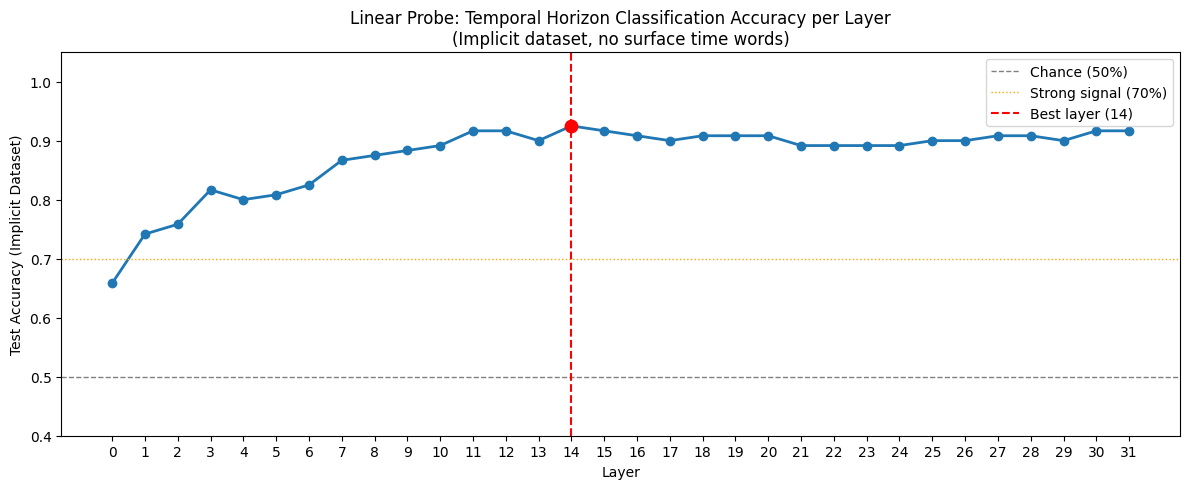


Best layer: 14  |  Test accuracy: 0.925

Top 5 layers:
 layer  test_accuracy  n_train  n_test
    14       0.925000      480     120
    11       0.916667      480     120
    12       0.916667      480     120
    15       0.916667      480     120
    30       0.916667      480     120


In [41]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_probes["layer"], df_probes["test_accuracy"], marker="o", linewidth=2, color="tab:blue")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (50%)")
ax.axhline(0.7, color="orange", linestyle=":", linewidth=1, label="Strong signal (70%)")

best_layer = int(df_probes.loc[df_probes["test_accuracy"].idxmax(), "layer"])
best_acc   = df_probes.loc[df_probes["test_accuracy"].idxmax(), "test_accuracy"]
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5, label=f"Best layer ({best_layer})")
ax.scatter([best_layer], [best_acc], color="red", zorder=5, s=80)

ax.set_xlabel("Layer")
ax.set_ylabel("Test Accuracy (Implicit Dataset)")
ax.set_title("Linear Probe: Temporal Horizon Classification Accuracy per Layer\n(Implicit dataset, no surface time words)")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "probe_accuracy_per_layer.png", dpi=150)
plt.show()

print(f"\nBest layer: {best_layer}  |  Test accuracy: {best_acc:.3f}")
print("\nTop 5 layers:")
print(df_probes.nlargest(5, "test_accuracy").to_string(index=False))

In [42]:
# Freshness check — confirm probes were just written
for fname in ["probe_accuracies.csv", "probe_accuracy_per_layer.png"]:
    fpath = OUT_DIR_PROBING / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

probe_accuracies.csv last modified: 1773939164
probe_accuracy_per_layer.png last modified: 1773939168


## Section 5 — Zero-Shot Cross-Dataset Generalization

We take the probes trained **only on implicit data** and evaluate them on the explicit
dataset — probes never saw any explicit time words during training.

**What this tells us:**
- High cross-dataset accuracy → the probe learned a genuinely semantic temporal direction
- Low cross-dataset accuracy → the probe learned something specific to the implicit dataset's
  linguistic patterns, not a universal temporal concept
- The difference between implicit test accuracy and cross-dataset accuracy measures
  how much of the temporal signal is surface-level vs. semantic

In [43]:
X_expl_np = torch.cat([acts_immediate, acts_long_term], dim=0).float().numpy()
y_expl    = np.array([0]*n_expl + [1]*n_expl)

cross_accs = []
for layer in tqdm(range(N_LAYERS), desc="Cross-dataset eval"):
    with open(OUT_DIR_PROBING / f"probe_layer_{layer:02d}.pkl", "rb") as f:
        probe = pickle.load(f)
    X_layer_expl = X_expl_np[:, layer, :]
    cross_acc = probe.score(X_layer_expl, y_expl)
    cross_accs.append(cross_acc)

df_probes["cross_dataset_accuracy"] = cross_accs
df_probes.to_csv(OUT_DIR_PROBING / "probe_accuracies.csv", index=False)

Cross-dataset eval: 100%|██████████| 32/32 [00:00<00:00, 78.30it/s]


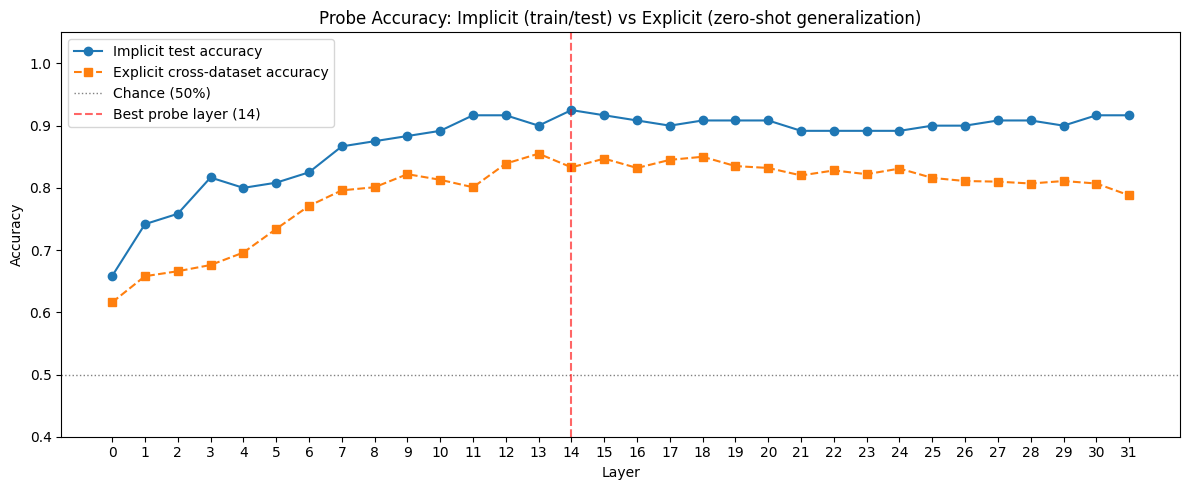


At best probe layer (14):
  Implicit test accuracy:          0.925
  Explicit cross-dataset accuracy: 0.833
  Generalization gap:              0.092


In [44]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_probes["layer"], df_probes["test_accuracy"],
        marker="o", label="Implicit test accuracy", color="tab:blue")
ax.plot(df_probes["layer"], df_probes["cross_dataset_accuracy"],
        marker="s", label="Explicit cross-dataset accuracy", color="tab:orange", linestyle="--")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Chance (50%)")
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5, alpha=0.6,
           label=f"Best probe layer ({best_layer})")

ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Probe Accuracy: Implicit (train/test) vs Explicit (zero-shot generalization)")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "probe_generalization.png", dpi=150)
plt.show()

print(f"\nAt best probe layer ({best_layer}):")
print(f"  Implicit test accuracy:          {df_probes.loc[best_layer, 'test_accuracy']:.3f}")
print(f"  Explicit cross-dataset accuracy: {df_probes.loc[best_layer, 'cross_dataset_accuracy']:.3f}")
generalization_gap = (df_probes.loc[best_layer, 'test_accuracy']
                      - df_probes.loc[best_layer, 'cross_dataset_accuracy'])
print(f"  Generalization gap:              {generalization_gap:.3f}")

## Section 6 — Redefine the CAA Steering Vector

We now compute the Contrastive Activation Addition vector strictly from the
**implicit** dataset means at the best probe layer.

This is the principled choice because:
1. The best probe layer is where temporal content is most linearly separable
2. The implicit dataset has no surface time words, so the direction captures
   *semantic* temporal reasoning rather than surface token patterns
3. Unit-normalisation makes the vector scale-agnostic for steering strength control

This replaces the Layer 31 explicit-dataset vector from Week 1.

Best probe layer: 14
Raw CAA vector norm at layer 14: 2.6209
Unit vector norm: 1.000000


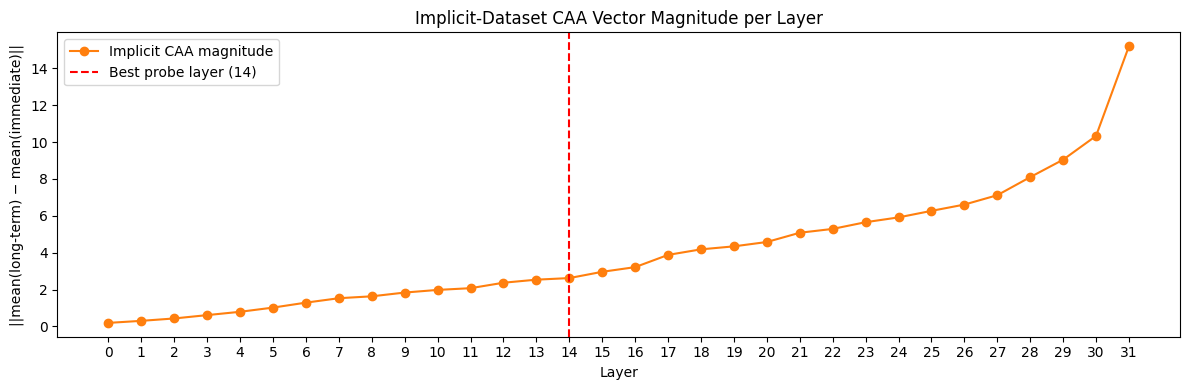


Saved to: /content/temporal-awareness/out/experiments/week2_probing
  implicit_caa_magnitude.png                     67.0 KB
  implicit_caa_vector_unit.npy                   16.5 KB
  implicit_caa_vector_unit.pt                    18.1 KB
  probe_accuracies.csv                           1.1 KB
  probe_accuracy_per_layer.png                   82.3 KB
  probe_generalization.png                       90.5 KB
  probe_layer_00.pkl                             33.5 KB
  probe_layer_01.pkl                             33.5 KB
  probe_layer_02.pkl                             33.5 KB
  probe_layer_03.pkl                             33.5 KB
  probe_layer_04.pkl                             33.5 KB
  probe_layer_05.pkl                             33.5 KB
  probe_layer_06.pkl                             33.5 KB
  probe_layer_07.pkl                             33.5 KB
  probe_layer_08.pkl                             33.5 KB
  probe_layer_09.pkl                             33.5 KB
  probe_layer_10.pkl

In [45]:
# Implicit CAA vector at every layer (for reference) and at the best layer (for steering)
diff_impl_all = (acts_long_term_impl.float() - acts_immediate_impl.float()).mean(dim=0)  # [32, 4096]
caa_norms_impl = diff_impl_all.norm(dim=-1)  # [32]

# Select best-probe layer
caa_vec_raw = diff_impl_all[best_layer]                   # [4096]
caa_vec_unit = caa_vec_raw / caa_vec_raw.norm().clamp(min=1e-8)  # unit norm

print(f"Best probe layer: {best_layer}")
print(f"Raw CAA vector norm at layer {best_layer}: {caa_vec_raw.norm():.4f}")
print(f"Unit vector norm: {caa_vec_unit.norm():.6f}")

# Plot CAA magnitude per layer for implicit dataset
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(caa_norms_impl.numpy(), marker="o", color="tab:orange", label="Implicit CAA magnitude")
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5,
           label=f"Best probe layer ({best_layer})")
ax.set_xlabel("Layer")
ax.set_ylabel("||mean(long-term) − mean(immediate)||")
ax.set_title("Implicit-Dataset CAA Vector Magnitude per Layer")
ax.legend()
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "implicit_caa_magnitude.png", dpi=150)
plt.show()

# Save the steering vector
torch.save(caa_vec_unit, OUT_DIR_PROBING / "implicit_caa_vector_unit.pt")
np.save(OUT_DIR_PROBING / "implicit_caa_vector_unit.npy", caa_vec_unit.numpy())

# Save metadata
meta = {
    "best_probe_layer": best_layer,
    "implicit_test_accuracy": float(df_probes.loc[best_layer, "test_accuracy"]),
    "explicit_cross_accuracy": float(df_probes.loc[best_layer, "cross_dataset_accuracy"]),
    "raw_caa_norm": float(caa_vec_raw.norm()),
    "vector_shape": list(caa_vec_unit.shape),
    "dataset": "temporal_scope_implicit_expanded_300",
    "n_implicit_pairs": n_impl,
    "note": "Unit-norm implicit CAA vector at best-probe layer. Use for Week 3 steering."
}
with open(OUT_DIR_PROBING / "steering_vector_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"\nSaved to: {OUT_DIR_PROBING}")
for p in sorted(OUT_DIR_PROBING.iterdir()):
    print(f"  {p.name:45s}  {p.stat().st_size/1e3:.1f} KB")

In [46]:
# Freshness check — confirm steering vector was just written
for fname in ["implicit_caa_vector_unit.pt", "steering_vector_meta.json"]:
    fpath = OUT_DIR_PROBING / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

implicit_caa_vector_unit.pt last modified: 1773939204
steering_vector_meta.json last modified: 1773939204


## Summary

| Metric | Value |
|--------|-------|
| Best probe layer | `best_layer` |
| Implicit test accuracy | X.XXX |
| Explicit cross-dataset accuracy | X.XXX |
| Generalization gap | X.XXX |
| New CAA vector source | Implicit dataset, best-probe layer |
| Saved vector | `week2_probing/implicit_caa_vector_unit.pt` |

**Interpretation:**
- If cross-dataset acc >> 50%: the temporal direction generalizes across datasets —
  it's a semantic feature, not surface-level memorization
- If cross-dataset acc ≈ implicit test acc: the two datasets share the same temporal
  subspace — strongest evidence for a genuine internal temporal representation
- The new steering vector should produce more coherent, semantically meaningful
  temporal shifts than the Layer 31 explicit-CAA vector from Week 1

**Next Steps (Week 3):**
- Use `implicit_caa_vector_unit.pt` at layer `best_layer` for steering experiments
- Test on neutral prompts with the corrected strength range [1, 3, 7, 15]
- Compare before/after outputs systematically across temporal categories

─── # Part 3: CAA Steering (Week 3) ───

**Goal:** Verify that the CAA direction found in Week 2 actually shifts generation toward longer or shorter temporal horizons.

**In-memory handoff:** activations and the `caa_vec_unit` vector are already computed above — no Drive reload needed.

**What we do:**
1. Compute per-layer CAA unit vectors (using implicit activations from Part 1)
2. Sweep prompts × strengths × conditions (baseline / long-term / short-term)
3. Optionally run a quantitative binary-choice logprob sweep
4. All behaviour is controlled by the **config cell immediately below**

In [47]:
# ═══════════════════════════════════════════════════════════════════════════════
# WEEK 3 CONFIGURATION — edit this cell to control the steering experiment
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Steering mode ─────────────────────────────────────────────────────────
# "single" → steer one layer only  (uses W3_STEER_LAYER)
# "multi"  → steer multiple layers simultaneously
W3_STEERING_MODE = "single"

# ── 2. Layer selection ───────────────────────────────────────────────────────
# [SINGLE] Which layer to steer. Defaults to best_layer from Week 2.
W3_STEER_LAYER = 13          # override with any int, e.g. 14

# [MULTI] How to pick layers:
#   "manual" → use the list in W3_STEER_LAYERS below
#   "top_k"  → auto-select W3_TOP_K_LAYERS layers with the highest raw CAA norm
W3_MULTI_LAYER_MODE = "top_k"
W3_STEER_LAYERS     = [10, 12, 14]   # used only when W3_MULTI_LAYER_MODE = "manual"
W3_TOP_K_LAYERS     = 3              # used only when W3_MULTI_LAYER_MODE = "top_k"

# ── 3. Steering strengths ────────────────────────────────────────────────────
# Choose ONE of three modes (set the others to None):
#
# MODE A — fraction of mean residual norm at W3_STEER_LAYER
#   0.10 = 10% of typical activation magnitude; 0.40 is a strong push
W3_STRENGTHS_FRAC = [0.05, 0.10, 0.20, 0.40]

# MODE B — multiple of the raw CAA vector norm at W3_STEER_LAYER
#   1.0 = exact CAA magnitude, 1.73 = stronger, 0.32 = weaker
#   Set to a list to activate; set to None to use MODE A instead
W3_STRENGTHS_CAA_MULTIPLE = None     # e.g. [0.32, 0.75, 1.0, 1.73]

# MODE C — absolute values (exact floats added to the residual stream)
#   Set to a list to activate; overrides both MODE A and MODE B
W3_STRENGTHS_ABSOLUTE = None         # e.g. [5.0, 10.0, 20.0]

# ── 4. Prompt selection ───────────────────────────────────────────────────────
# All available prompts (copy indices into W3_SELECTED_PROMPTS to pick a subset):
#
#   NEUTRAL (open-ended decision stems, no temporal cues):
#     [1]  'When managing a new project, my primary focus is:'
#     [2]  'The best way to allocate a sudden surplus of budget is:'
#     [3]  'When building a team, the most important quality to look for is:'
#     [4]  'In the face of an unexpected setback, the right response is:'
#     [5]  'When developing a new skill, the most effective approach is:'
#
#   FORCING (direct preference completions):
#     [6]  'What matters most to me is:'
#     [7]  'If I could only focus on one thing, it would be:'
#     [8]  'Above all else, I value:'
#     [9]  'The thing that guides every decision I make is:'
#     [10] 'When I think about what I want, the answer is always:'
#
# W3_PROMPT_SET: "neutral" (1-5), "forcing" (6-10), or "both" (all 10)
W3_PROMPT_SET = "both"

# W3_SELECTED_PROMPTS: override W3_PROMPT_SET with specific indices, or None.
# e.g. [1, 6] → first neutral + first forcing only (fast: 2 prompts × 9 conditions)
W3_SELECTED_PROMPTS = [8]

# ── 5. Generation settings ────────────────────────────────────────────────────
W3_TEMPERATURE = 0.3      # 0 = greedy (deterministic); higher = more varied
W3_MAX_TOKENS  = 120      # max new tokens per generation

# ── 6. Binary choice evaluation ───────────────────────────────────────────────
W3_RUN_BINARY_CHOICE = True   # set False to skip the logprob P(long-term) sweep

# ── Display (no need to edit) ─────────────────────────────────────────────────
print("Week 3 configuration:")
print(f"  Steering mode       : {W3_STEERING_MODE}")
if W3_STEERING_MODE == "single":
    print(f"  Steer layer         : {W3_STEER_LAYER}")
else:
    print(f"  Multi-layer mode    : {W3_MULTI_LAYER_MODE}")
    if W3_MULTI_LAYER_MODE == "manual":
        print(f"  Steer layers        : {W3_STEER_LAYERS}")
    else:
        print(f"  Top-k layers        : {W3_TOP_K_LAYERS}")
if W3_STRENGTHS_ABSOLUTE is not None:
    print(f"  Strength mode       : MODE C (absolute) → {W3_STRENGTHS_ABSOLUTE}")
elif W3_STRENGTHS_CAA_MULTIPLE is not None:
    print(f"  Strength mode       : MODE B (CAA multiple) → {W3_STRENGTHS_CAA_MULTIPLE}× raw CAA norm")
else:
    print(f"  Strength mode       : MODE A (frac of resid norm) → {W3_STRENGTHS_FRAC}")
_ps = W3_SELECTED_PROMPTS if W3_SELECTED_PROMPTS else f"set={W3_PROMPT_SET}"
print(f"  Prompts             : {_ps}")
print(f"  Temperature         : {W3_TEMPERATURE}  |  Max tokens: {W3_MAX_TOKENS}")
print(f"  Binary choice       : {W3_RUN_BINARY_CHOICE}")

Week 3 configuration:
  Steering mode       : single
  Steer layer         : 13
  Strength mode       : MODE A (frac of resid norm) → [0.05, 0.1, 0.2, 0.4]
  Prompts             : [8]
  Temperature         : 0.3  |  Max tokens: 120
  Binary choice       : True


## Section 7 — CAA Vectors (In-Memory)

Build per-layer CAA unit vectors from the implicit activations already in memory.
No Drive reload needed — `acts_immediate_impl` / `acts_long_term_impl` are passed directly from Part 1.

In [48]:
from src.inference.interventions import steering as make_steering_intervention

# ── Per-layer CAA unit vectors (all layers) ───────────────────────────────────
_acts_imm = acts_immediate_impl.float()
_acts_lt  = acts_long_term_impl.float()
n_w3_layers = _acts_imm.shape[1]

w3_caa_units    = {}    # layer → np.ndarray [d_model], float32
w3_caa_raw_norm = {}    # layer → float  (used for top-k selection and MODE B strengths)

for L in range(n_w3_layers):
    raw = (_acts_lt[:, L, :] - _acts_imm[:, L, :]).mean(dim=0)
    w3_caa_raw_norm[L] = float(raw.norm())
    w3_caa_units[L]    = (raw / raw.norm().clamp(min=1e-8)).numpy().astype("float32")

print(f"CAA unit vectors computed for all {n_w3_layers} layers.")

# ── Resolve active steering layers from config ────────────────────────────────
if W3_STEERING_MODE == "multi":
    if W3_MULTI_LAYER_MODE == "top_k":
        _sorted_by_norm = sorted(w3_caa_raw_norm, key=w3_caa_raw_norm.__getitem__, reverse=True)
        _steer_layers_active = sorted(_sorted_by_norm[:W3_TOP_K_LAYERS])
        print(f"\nTop-{W3_TOP_K_LAYERS} layers by raw CAA norm → {_steer_layers_active}")
    else:
        _steer_layers_active = W3_STEER_LAYERS
        print(f"\nManual multi-layer selection → {_steer_layers_active}")
else:
    _steer_layers_active = [W3_STEER_LAYER]
    print(f"\nSingle-layer mode → layer {W3_STEER_LAYER}")

# ── Print per-layer norms, highlight active layers ────────────────────────────
print(f"\nPer-layer raw CAA norms:")
for L in range(n_w3_layers):
    marker = " ◄ ACTIVE" if L in _steer_layers_active else ""
    print(f"  Layer {L:2d}: {w3_caa_raw_norm[L]:.4f}{marker}")

# ── Resolve strengths (priority: MODE C > MODE B > MODE A) ───────────────────
_ref_layer_acts  = _acts_imm[:, W3_STEER_LAYER, :]
_mean_resid_norm = float(_ref_layer_acts.norm(dim=-1).mean())
_caa_norm_ref    = w3_caa_raw_norm[W3_STEER_LAYER]

if W3_STRENGTHS_ABSOLUTE is not None:
    W3_STRENGTHS   = W3_STRENGTHS_ABSOLUTE
    _strength_desc = f"MODE C (absolute): {W3_STRENGTHS}"
elif W3_STRENGTHS_CAA_MULTIPLE is not None:
    W3_STRENGTHS   = [round(m * _caa_norm_ref, 4) for m in W3_STRENGTHS_CAA_MULTIPLE]
    _strength_desc = (
        f"MODE B (×CAA norm={_caa_norm_ref:.3f}): "
        f"{W3_STRENGTHS_CAA_MULTIPLE} → {W3_STRENGTHS}"
    )
else:
    W3_STRENGTHS   = [round(f * _mean_resid_norm, 3) for f in W3_STRENGTHS_FRAC]
    _strength_desc = (
        f"MODE A (frac of resid norm={_mean_resid_norm:.3f}): "
        f"{W3_STRENGTHS_FRAC} → {W3_STRENGTHS}"
    )

print(f"\nStrength resolution: {_strength_desc}")
print(f"  CAA raw norm at layer {W3_STEER_LAYER}: {_caa_norm_ref:.4f}")
print(f"  Mean resid norm at layer {W3_STEER_LAYER}: {_mean_resid_norm:.3f}")
print(f"  Final W3_STRENGTHS: {W3_STRENGTHS}")

# ── Save CAA vector at W3_STEER_LAYER ─────────────────────────────────────────
W3_OUT_DIR = get_experiment_dir() / "week3_steering"
W3_OUT_DIR.mkdir(parents=True, exist_ok=True)
_caa_tensor = torch.tensor(w3_caa_units[W3_STEER_LAYER])
torch.save(_caa_tensor, W3_OUT_DIR / f"caa_vec_unit_layer{W3_STEER_LAYER}.pt")
np.save(W3_OUT_DIR / f"caa_vec_unit_layer{W3_STEER_LAYER}.npy", w3_caa_units[W3_STEER_LAYER])
print(f"\nSaved CAA vector (layer {W3_STEER_LAYER}) → {W3_OUT_DIR}")

CAA unit vectors computed for all 32 layers.

Single-layer mode → layer 13

Per-layer raw CAA norms:
  Layer  0: 0.1908
  Layer  1: 0.3018
  Layer  2: 0.4311
  Layer  3: 0.6127
  Layer  4: 0.7926
  Layer  5: 1.0202
  Layer  6: 1.2893
  Layer  7: 1.5289
  Layer  8: 1.6319
  Layer  9: 1.8357
  Layer 10: 1.9790
  Layer 11: 2.0731
  Layer 12: 2.3687
  Layer 13: 2.5346 ◄ ACTIVE
  Layer 14: 2.6209
  Layer 15: 2.9614
  Layer 16: 3.2148
  Layer 17: 3.8785
  Layer 18: 4.1793
  Layer 19: 4.3413
  Layer 20: 4.5774
  Layer 21: 5.0795
  Layer 22: 5.2874
  Layer 23: 5.6515
  Layer 24: 5.9120
  Layer 25: 6.2659
  Layer 26: 6.6073
  Layer 27: 7.1156
  Layer 28: 8.0959
  Layer 29: 9.0418
  Layer 30: 10.3312
  Layer 31: 15.1984

Strength resolution: MODE A (frac of resid norm=10.011): [0.05, 0.1, 0.2, 0.4] → [0.501, 1.001, 2.002, 4.004]
  CAA raw norm at layer 13: 2.5346
  Mean resid norm at layer 13: 10.011
  Final W3_STRENGTHS: [0.501, 1.001, 2.002, 4.004]

Saved CAA vector (layer 13) → /content/tempo

## Section 8 — Prompt Library & Selection

Two prompt sets:
- **Neutral** (5): open-ended decision stems, no temporal keywords — tests whether steering shifts framing organically
- **Forcing** (5): direct preference completions — cleaner window into which horizon is activated

`W3_SELECTED_PROMPTS` (config cell) overrides `W3_PROMPT_SET` if set.

In [49]:
_NEUTRAL_PROMPTS = [
    # ── Neutral decision-making (no temporal cues) ──────────────────────────
    'When managing a new project, my primary focus is:',
    'The best way to allocate a sudden surplus of budget is:',
    'When building a team, the most important quality to look for is:',
    'In the face of an unexpected setback, the right response is:',
    'When developing a new skill, the most effective approach is:',
]

_FORCING_PROMPTS = [
    # ── Direct preference-forcing ────────────────────────────────────────────
    'What matters most to me is:',
    'If I could only focus on one thing, it would be:',
    'Above all else, I value:',
    'The thing that guides every decision I make is:',
    'When I think about what I want, the answer is always:',
]

# ── All prompts with tags (1-indexed to match W3_SELECTED_PROMPTS) ────────────
_ALL_PROMPTS = (
    [{'text': p, 'set': 'neutral', 'idx': i + 1}      for i, p in enumerate(_NEUTRAL_PROMPTS)]
    + [{'text': p, 'set': 'forcing', 'idx': i + 6}    for i, p in enumerate(_FORCING_PROMPTS)]
)

# ── Apply config selection ────────────────────────────────────────────────────
if W3_SELECTED_PROMPTS is not None:
    _idx_set = set(W3_SELECTED_PROMPTS)
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['idx'] in _idx_set]
elif W3_PROMPT_SET == "neutral":
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['set'] == 'neutral']
elif W3_PROMPT_SET == "forcing":
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['set'] == 'forcing']
else:  # "both"
    W3_ACTIVE_PROMPTS = _ALL_PROMPTS

print(f"Active prompts ({len(W3_ACTIVE_PROMPTS)}):")
for p in W3_ACTIVE_PROMPTS:
    print(f"  [{p['idx']:2d}] [{p['set']}] {p['text']}")

Active prompts (1):
  [ 8] [forcing] Above all else, I value:


## Section 9 — Steering Sweep

Runs the sweep according to `W3_STEERING_MODE`:

- **single**: adds `caa_unit[W3_STEER_LAYER] * strength` to the residual stream at one layer
- **multi**: adds `caa_unit[L] * strength` at *each* layer in `W3_STEER_LAYERS` at **full** strength (not divided — splitting the budget weakens the signal)

Positive strength → long-term direction; negative → short-term.

In [50]:
def _generate_with_hooks(prompt: str, hook_pairs: list) -> str:
    """Generate text with custom forward hooks active (TransformerLens)."""
    formatted  = runner.apply_chat_template(prompt)
    input_ids  = runner._backend.encode(formatted)
    prompt_len = input_ids.shape[1]
    gen_kwargs = {
        "max_new_tokens":    W3_MAX_TOKENS,
        "do_sample":         W3_TEMPERATURE > 0,
        "temperature":       W3_TEMPERATURE,
        "stop_at_eos":       True,
        "verbose":           False,
        "use_past_kv_cache": False,  # must be False when hooks are active
    }
    with torch.no_grad():
        with runner._model.hooks(fwd_hooks=hook_pairs):
            output_ids = runner._model.generate(input_ids, **gen_kwargs)
    return runner._backend.decode(output_ids[0, prompt_len:]).strip()


def _make_hooks(layers: list[int], direction: float, strength: float) -> list:
    """Build hook pairs for residual-stream addition at each specified layer."""
    pairs = []
    for L in layers:
        vec = torch.tensor(
            w3_caa_units[L] * direction * strength,
            dtype=runner.dtype,
            device=runner.device,
        )
        pairs.append(
            (f"blocks.{L}.hook_resid_post", lambda act, hook=None, v=vec: act + v)
        )
    return pairs


# ── Condition list ─────────────────────────────────────────────────────────────
_steer_layers_active = (
    W3_STEER_LAYERS if W3_STEERING_MODE == "multi" else [W3_STEER_LAYER]
)

W3_CONDITIONS = (
    [("baseline", None)]
    + [(f"LT_{s}",  (+1.0, s)) for s in W3_STRENGTHS]
    + [(f"ST_{s}",  (-1.0, s)) for s in W3_STRENGTHS]
)

# ── Run sweep ──────────────────────────────────────────────────────────────────
W3_RESULTS = []
total = len(W3_ACTIVE_PROMPTS) * len(W3_CONDITIONS)
done  = 0

for pdata in W3_ACTIVE_PROMPTS:
    entry = {"prompt": pdata["text"], "set": pdata["set"], "idx": pdata["idx"], "conditions": {}}

    for label, args in W3_CONDITIONS:
        if args is None:
            # Baseline: plain generate (no hooks)
            text = runner.generate(
                pdata["text"],
                max_new_tokens=W3_MAX_TOKENS,
                temperature=W3_TEMPERATURE,
            )
        else:
            direction, strength = args
            hooks = _make_hooks(_steer_layers_active, direction, strength)
            text  = _generate_with_hooks(pdata["text"], hooks)

        entry["conditions"][label] = text.strip()
        done += 1
        print(f"  [{done:3d}/{total}] prompt={pdata['idx']:2d} ({pdata['set']})  {label}")

    W3_RESULTS.append(entry)

print(f"\nSweep complete ({W3_STEERING_MODE}-layer, layers={_steer_layers_active}).")

  [  1/9] prompt= 8 (forcing)  baseline
  [  2/9] prompt= 8 (forcing)  LT_0.501
  [  3/9] prompt= 8 (forcing)  LT_1.001
  [  4/9] prompt= 8 (forcing)  LT_2.002
  [  5/9] prompt= 8 (forcing)  LT_4.004
  [  6/9] prompt= 8 (forcing)  ST_0.501
  [  7/9] prompt= 8 (forcing)  ST_1.001
  [  8/9] prompt= 8 (forcing)  ST_2.002
  [  9/9] prompt= 8 (forcing)  ST_4.004

Sweep complete (single-layer, layers=[13]).


## Section 10 — Results Display

In [51]:
import json
from IPython.display import display, Markdown

_NL = chr(10)
_mode_label = (
    f"Single-layer L{W3_STEER_LAYER}"
    if W3_STEERING_MODE == "single"
    else f"Multi-layer {_steer_layers_active}"
)


def _abbrev(text: str, n: int = 240) -> str:
    text = " ".join(text.split()).replace("|", "/")
    return text if len(text) <= n else text[:n].rsplit(" ", 1)[0] + "..."


def _render_entry(entry: dict) -> str:
    cond = entry["conditions"]
    rows = [
        "| Condition | Strength | Completion |",
        "|-----------|:--------:|------------|",
        f"| **Baseline** | — | {_abbrev(cond['baseline'])} |",
    ]
    for s in W3_STRENGTHS:
        lt = _abbrev(cond.get(f"LT_{s}", "(missing)"))
        st = _abbrev(cond.get(f"ST_{s}", "(missing)"))
        rows.append(f"| ↑ Long-term  | +{s} | {lt} |")
        rows.append(f"| ↓ Short-term | −{s} | {st} |")
    header = (
        f"### [{entry['set']}] Prompt {entry['idx']}{_NL}{_NL}"
        f"> {entry['prompt']}{_NL}{_NL}"
    )
    return header + _NL.join(rows)


print(f"{'=' * 60}")
print(f"STEERING RESULTS  —  {_mode_label}")
print(f"{'=' * 60}")
for entry in W3_RESULTS:
    display(Markdown(_render_entry(entry)))
    print()

# ── Save to JSON ───────────────────────────────────────────────────────────────
_save_name = (
    f"steering_results_single_L{W3_STEER_LAYER}.json"
    if W3_STEERING_MODE == "single"
    else f"steering_results_multi_{'_'.join(str(l) for l in _steer_layers_active)}.json"
)
_save_data = {
    "mode":              W3_STEERING_MODE,
    "steer_layers":      _steer_layers_active,
    "strengths":         W3_STRENGTHS,
    "strengths_frac":    W3_STRENGTHS_FRAC,
    "mean_resid_norm":   round(_mean_resid_norm, 4),
    "temperature":       W3_TEMPERATURE,
    "results":           W3_RESULTS,
}
with open(W3_OUT_DIR / _save_name, "w") as f:
    json.dump(_save_data, f, indent=2)
print(f"Saved: {W3_OUT_DIR / _save_name}")

STEERING RESULTS  —  Single-layer L13


### [forcing] Prompt 8

> Above all else, I value:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | honesty, integrity, and the ability to laugh at myself. I am a self-starter who is always looking for ways to improve myself and those around me. I am a team player who is always willing to go the extra mile to get the job done. I am a... |
| ↑ Long-term  | +0.501 | honesty, integrity, and a good sense of humor. I am looking for someone who is honest, intelligent, and has a good sense of humor. I am also looking for someone who is willing to work hard and who is not afraid to take risks. I am looking... |
| ↓ Short-term | −0.501 | The ability to learn from my mistakes, and to make changes as needed. I value the ability to be honest and straightforward. I value the ability to be open and receptive to new ideas and new ways of doing things. I value the ability to be a... |
| ↑ Long-term  | +1.001 | the opportunity to learn from the people I work with; the chance to make a difference in the lives of others; and the ability to make a positive impact on the world around me. I am passionate about: making a positive impact on the world... |
| ↓ Short-term | −1.001 | 1. The ability to learn from my mistakes. 2. The ability to learn from my mistakes. 3. The ability to learn from my mistakes. 4. The ability to learn from my mistakes. 5. The ability to learn from my mistakes. 6. The ability to learn from... |
| ↑ Long-term  | +2.002 | the ability to think for myself, to question, to be curious, to be creative, to be open to new ideas, to be able to learn and grow, to be able to communicate effectively, to be able to work with others, to be able to lead, to be able to be... |
| ↓ Short-term | −2.002 | honesty, integrity, and respect. I have a strong sense of fairness and justice, and I am committed to treating others with dignity and respect. I am a hard worker and I am not afraid to put in the time and effort to get the job done. I am... |
| ↑ Long-term  | +4.004 | a sense of humor; a sense of adventure; a sense of community; a sense of purpose; a sense of play; a sense of self; a sense of place; a sense of home; a sense of family; a sense of place; a sense of place; a sense of place; a sense of... |
| ↓ Short-term | −4.004 | My family and friends, my health, my home, my job, my car, my money, my time, my food, my clothes, my bed, my TV, my radio, my computer, my phone, my email, my Facebook, my Twitter, my Instagram, my Snapchat, my YouTube, my Tumblr, my... |


Saved: /content/temporal-awareness/out/experiments/week3_steering/steering_results_single_L13.json


## Section 11 — Binary Choice Logprob Sweep (Quantitative)

Each question offers an **immediate** option (A) and a **long-term** option (B).
We measure the raw logprob of the branch token `(A)` vs `(B)` — no text parsing needed.

`P(long-term)` = softmax over the two logprobs.

**Design note:** These questions are deliberately more **balanced** than the previous version.
Most prior questions had baseline P(LT) > 0.9, leaving no headroom to observe steering.
Questions here are chosen so the model is closer to 50/50 at baseline — making the
steering signal visible even at moderate strengths.

Controlled by `W3_RUN_BINARY_CHOICE` in the config cell.

In [58]:
if not W3_RUN_BINARY_CHOICE:
    print("W3_RUN_BINARY_CHOICE=False — skipping binary choice sweep.")
else:
    import math
    from src.binary_choice import BinaryChoiceRunner

    # Upgrade runner in-place — no model reload
    runner.__class__ = BinaryChoiceRunner

    # ── Binary choice questions ───────────────────────────────────────────────
    # A = immediate,  B = long-term  (consistent across all questions).
    # Chosen for near-50/50 baseline so that steering signal has room to show.
    BINARY_QUESTIONS = [
        {
            "question": (
                "A startup facing a cash crunch should:\n"
                "(A) Cut costs immediately to survive the next 90 days\n"
                "(B) Stay the course on the long-term product roadmap"
            ),
        },
        {
            "question": (
                "A student with an exam tomorrow and a project due in three months should tonight:\n"
                "(A) Study hard for tomorrow's exam\n"
                "(B) Work on the long-term project instead"
            ),
        },
        {
            "question": (
                "When allocating a team's sprint capacity, the better choice is:\n"
                "(A) Fixing the bug that is breaking users right now\n"
                "(B) Rewriting the architecture to prevent future bugs"
            ),
        },
        {
            "question": (
                "After an unexpected setback, the wiser first move is:\n"
                "(A) Patch the immediate damage quickly and move on\n"
                "(B) Pause, reflect, and redesign to avoid recurrence"
            ),
        },
        {
            "question": (
                "When managing personal finances, it is more important to:\n"
                "(A) Cover this month's bills and feel stable now\n"
                "(B) Invest consistently for compounding returns over decades"
            ),
        },
        {
            "question": (
                "A new manager joining a struggling team should first:\n"
                "(A) Address the most visible complaints to win quick trust\n"
                "(B) Diagnose root causes and build a culture that lasts"
            ),
        },
    ]

    CHOICE_PREFIX = "\nPlease respond only 'A' or 'B' \nThe better choice is: "
    LABELS = ("A", "B")   # A = immediate, B = long-term

    def _softmax2(lp_a: float, lp_b: float) -> tuple:
        m = max(lp_a, lp_b)
        ea, eb = math.exp(lp_a - m), math.exp(lp_b - m)
        s = ea + eb
        return ea / s, eb / s

    def _p_lt(question: str, hook_pairs: list = None) -> float:
        """Return P(long-term) = P(B) for the question, with optional hooks."""
        if hook_pairs:
            with runner._model.hooks(fwd_hooks=hook_pairs):
                result = runner.choose(
                    prompt=question, choice_prefix=CHOICE_PREFIX, labels=LABELS
                )
        else:
            result = runner.choose(
                prompt=question, choice_prefix=CHOICE_PREFIX, labels=LABELS
            )
        lp_a, lp_b = result._divergent_logprobs
        _, p = _softmax2(lp_a, lp_b)
        return p

    # ── Build conditions for binary choice ────────────────────────────────────
    BC_CONDITIONS = (
        [("baseline", [])]
        + [(f"LT_{s}", _make_hooks(_steer_layers_active, +1.0, s)) for s in W3_STRENGTHS]
        + [(f"ST_{s}", _make_hooks(_steer_layers_active, -1.0, s)) for s in W3_STRENGTHS]
    )

    bc_results = []
    total_bc = len(BINARY_QUESTIONS) * len(BC_CONDITIONS)
    done_bc  = 0

    for qi, q in enumerate(BINARY_QUESTIONS):
        row = {"question": q["question"], "conditions": {}}
        for label, hooks in BC_CONDITIONS:
            p = _p_lt(q["question"], hooks or None)
            row["conditions"][label] = round(p, 4)
            done_bc += 1
            print(f"  [{done_bc:3d}/{total_bc}] Q{qi + 1} {label:<18}  P(LT)={p:.3f}")
        bc_results.append(row)

    print("\nBinary choice sweep complete.")

  [  1/54] Q1 baseline            P(LT)=0.186
  [  2/54] Q1 LT_0.501            P(LT)=0.184
  [  3/54] Q1 LT_1.001            P(LT)=0.181
  [  4/54] Q1 LT_2.002            P(LT)=0.183
  [  5/54] Q1 LT_4.004            P(LT)=0.191
  [  6/54] Q1 ST_0.501            P(LT)=0.188
  [  7/54] Q1 ST_1.001            P(LT)=0.185
  [  8/54] Q1 ST_2.002            P(LT)=0.169
  [  9/54] Q1 ST_4.004            P(LT)=0.118
  [ 10/54] Q2 baseline            P(LT)=0.343
  [ 11/54] Q2 LT_0.501            P(LT)=0.338
  [ 12/54] Q2 LT_1.001            P(LT)=0.333
  [ 13/54] Q2 LT_2.002            P(LT)=0.328
  [ 14/54] Q2 LT_4.004            P(LT)=0.307
  [ 15/54] Q2 ST_0.501            P(LT)=0.343
  [ 16/54] Q2 ST_1.001            P(LT)=0.338
  [ 17/54] Q2 ST_2.002            P(LT)=0.301
  [ 18/54] Q2 ST_4.004            P(LT)=0.185
  [ 19/54] Q3 baseline            P(LT)=0.232
  [ 20/54] Q3 LT_0.501            P(LT)=0.230
  [ 21/54] Q3 LT_1.001            P(LT)=0.229
  [ 22/54] Q3 LT_2.002            

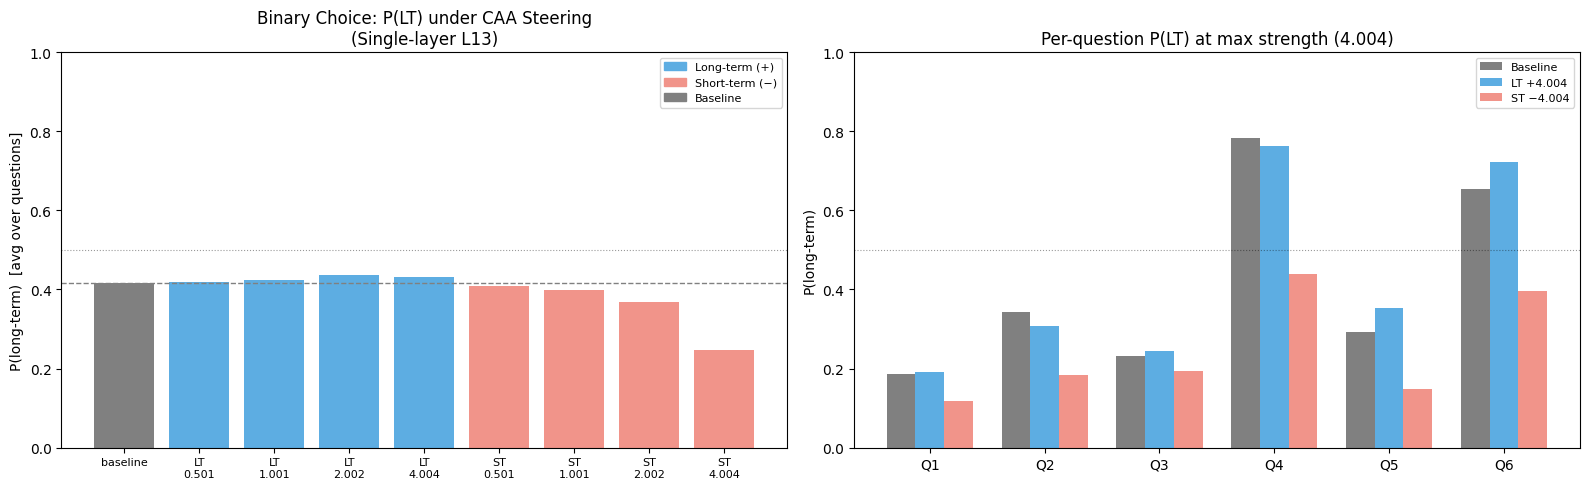


Condition               Q1    Q2    Q3    Q4    Q5    Q6    Mean
------------------------------------------------------------------------------
baseline                0.186  0.343  0.232  0.783  0.293  0.655  0.415
LT_0.501                0.184  0.338  0.230  0.785  0.306  0.669  0.419
LT_1.001                0.181  0.333  0.229  0.791  0.321  0.684  0.423
LT_2.002                0.183  0.328  0.234  0.799  0.356  0.719  0.436
LT_4.004                0.191  0.307  0.245  0.763  0.352  0.723  0.430
ST_0.501                0.188  0.343  0.230  0.775  0.278  0.641  0.409
ST_1.001                0.185  0.338  0.227  0.762  0.261  0.626  0.400
ST_2.002                0.169  0.301  0.219  0.704  0.226  0.585  0.367
ST_4.004                0.118  0.185  0.194  0.440  0.149  0.396  0.247

Saved: /content/temporal-awareness/out/experiments/week3_steering/binary_choice_results.json


In [59]:
if W3_RUN_BINARY_CHOICE and bc_results:
    import matplotlib.patches as mpatches

    bc_labels = [label for label, _ in BC_CONDITIONS]
    avg_p_lt  = {
        label: np.mean([r["conditions"][label] for r in bc_results])
        for label in bc_labels
    }
    baseline_p = avg_p_lt["baseline"]

    def _bc_colour(label: str) -> str:
        if label == "baseline":  return "gray"
        if label.startswith("LT_"): return "#5dade2"
        return "#f1948a"

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ── Left: average P(LT) per condition ─────────────────────────────────────
    ax = axes[0]
    bars = ax.bar(
        range(len(bc_labels)),
        [avg_p_lt[l] for l in bc_labels],
        color=[_bc_colour(l) for l in bc_labels],
    )
    ax.axhline(baseline_p, color="gray", linestyle="--", linewidth=1,
               label=f"Baseline ({baseline_p:.3f})")
    ax.axhline(0.5, color="black", linestyle=":", linewidth=0.8, alpha=0.4)
    ax.set_xticks(range(len(bc_labels)))
    ax.set_xticklabels([l.replace("_", "\n") for l in bc_labels], fontsize=8)
    ax.set_ylabel("P(long-term)  [avg over questions]")
    ax.set_title(f"Binary Choice: P(LT) under CAA Steering\n({_mode_label})")
    ax.set_ylim(0, 1)
    ax.legend(handles=[
        mpatches.Patch(color="#5dade2", label="Long-term (+)"),
        mpatches.Patch(color="#f1948a", label="Short-term (−)"),
        mpatches.Patch(color="gray",    label="Baseline"),
    ], fontsize=8, loc="upper right")

    # ── Right: P(LT) per question at strongest strength ────────────────────────
    ax = axes[1]
    _strongest = W3_STRENGTHS[-1]
    _lt_label  = f"LT_{_strongest}"
    _st_label  = f"ST_{_strongest}"
    q_labels   = [f"Q{i+1}" for i in range(len(bc_results))]
    p_base     = [r["conditions"]["baseline"] for r in bc_results]
    p_lt_strong = [r["conditions"].get(_lt_label, float("nan")) for r in bc_results]
    p_st_strong = [r["conditions"].get(_st_label, float("nan")) for r in bc_results]
    x = np.arange(len(q_labels))
    w = 0.25
    ax.bar(x - w, p_base,      width=w, label="Baseline",       color="gray")
    ax.bar(x,     p_lt_strong, width=w, label=f"LT +{_strongest}", color="#5dade2")
    ax.bar(x + w, p_st_strong, width=w, label=f"ST −{_strongest}", color="#f1948a")
    ax.axhline(0.5, color="black", linestyle=":", linewidth=0.8, alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("P(long-term)")
    ax.set_title(f"Per-question P(LT) at max strength ({_strongest})")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / "binary_choice_p_longterm.png", dpi=150)
    plt.show()

    # ── Numeric table ──────────────────────────────────────────────────────────
    print(f"\n{'Condition':<22}", end="")
    for qi in range(len(bc_results)):
        print(f"  Q{qi+1}  ", end="")
    print("  Mean")
    print("-" * (22 + 8 * len(bc_results) + 8))
    for label in bc_labels:
        vals = [bc_results[qi]["conditions"][label] for qi in range(len(bc_results))]
        print(f"{label:<22}", end="")
        for v in vals:
            print(f"  {v:.3f}", end="")
        print(f"  {np.mean(vals):.3f}")

    # ── Save ───────────────────────────────────────────────────────────────────
    with open(W3_OUT_DIR / "binary_choice_results.json", "w") as f:
        json.dump({
            "mode": W3_STEERING_MODE,
            "steer_layers": _steer_layers_active,
            "strengths": W3_STRENGTHS,
            "questions": BINARY_QUESTIONS,
            "results": bc_results,
        }, f, indent=2)
    print(f"\nSaved: {W3_OUT_DIR / 'binary_choice_results.json'}")

## Section 12 — Top-5 Token Distribution at Branch Point

For each binary question we run **three** forward passes at the choice position:
- **Baseline** (no hooks)
- **Max LT** (strongest long-term steering)
- **Max ST** (strongest short-term steering)

We extract the full vocabulary logit distribution at the last token position
(right after the `CHOICE_PREFIX`) and plot the top-5 tokens for each condition side-by-side.
This shows *what the model wants to say* before and after steering — not just the A/B split.

  Q1 Baseline: [(' A', 0.328), (' (', 0.169), (' B', 0.08), ('<|end_of_text|>', 0.051), (" '", 0.032)]
  Q1 LT +4.004: [(' A', 0.211), (' (', 0.113), ('<|end_of_text|>', 0.063), (' B', 0.051), (' [', 0.035)]
  Q1 ST −4.004: [(' A', 0.397), (' (', 0.175), (' B', 0.069), (" '", 0.051), ('<|end_of_text|>', 0.033)]
  Q2 Baseline: [(' A', 0.246), (' (', 0.096), (' B', 0.085), ('<|end_of_text|>', 0.042), ('0', 0.029)]
  Q2 LT +4.004: [(' A', 0.137), (' (', 0.075), (' B', 0.053), ('<|end_of_text|>', 0.041), ('1', 0.032)]
  Q2 ST −4.004: [(' A', 0.373), (' (', 0.103), (' B', 0.084), ('1', 0.042), ('0', 0.026)]
  Q3 Baseline: [(' A', 0.337), (' (', 0.132), (' B', 0.086), ('<|end_of_text|>', 0.086), (' [', 0.02)]
  Q3 LT +4.004: [(' A', 0.181), ('<|end_of_text|>', 0.104), (' (', 0.09), (' B', 0.053), (' [', 0.049)]
  Q3 ST −4.004: [(' A', 0.371), (' (', 0.202), (' B', 0.09), ('<|end_of_text|>', 0.038), ('1', 0.029)]
  Q4 Baseline: [(' B', 0.31), (' (', 0.132), (' A', 0.122), ('<|end_of_text|>', 

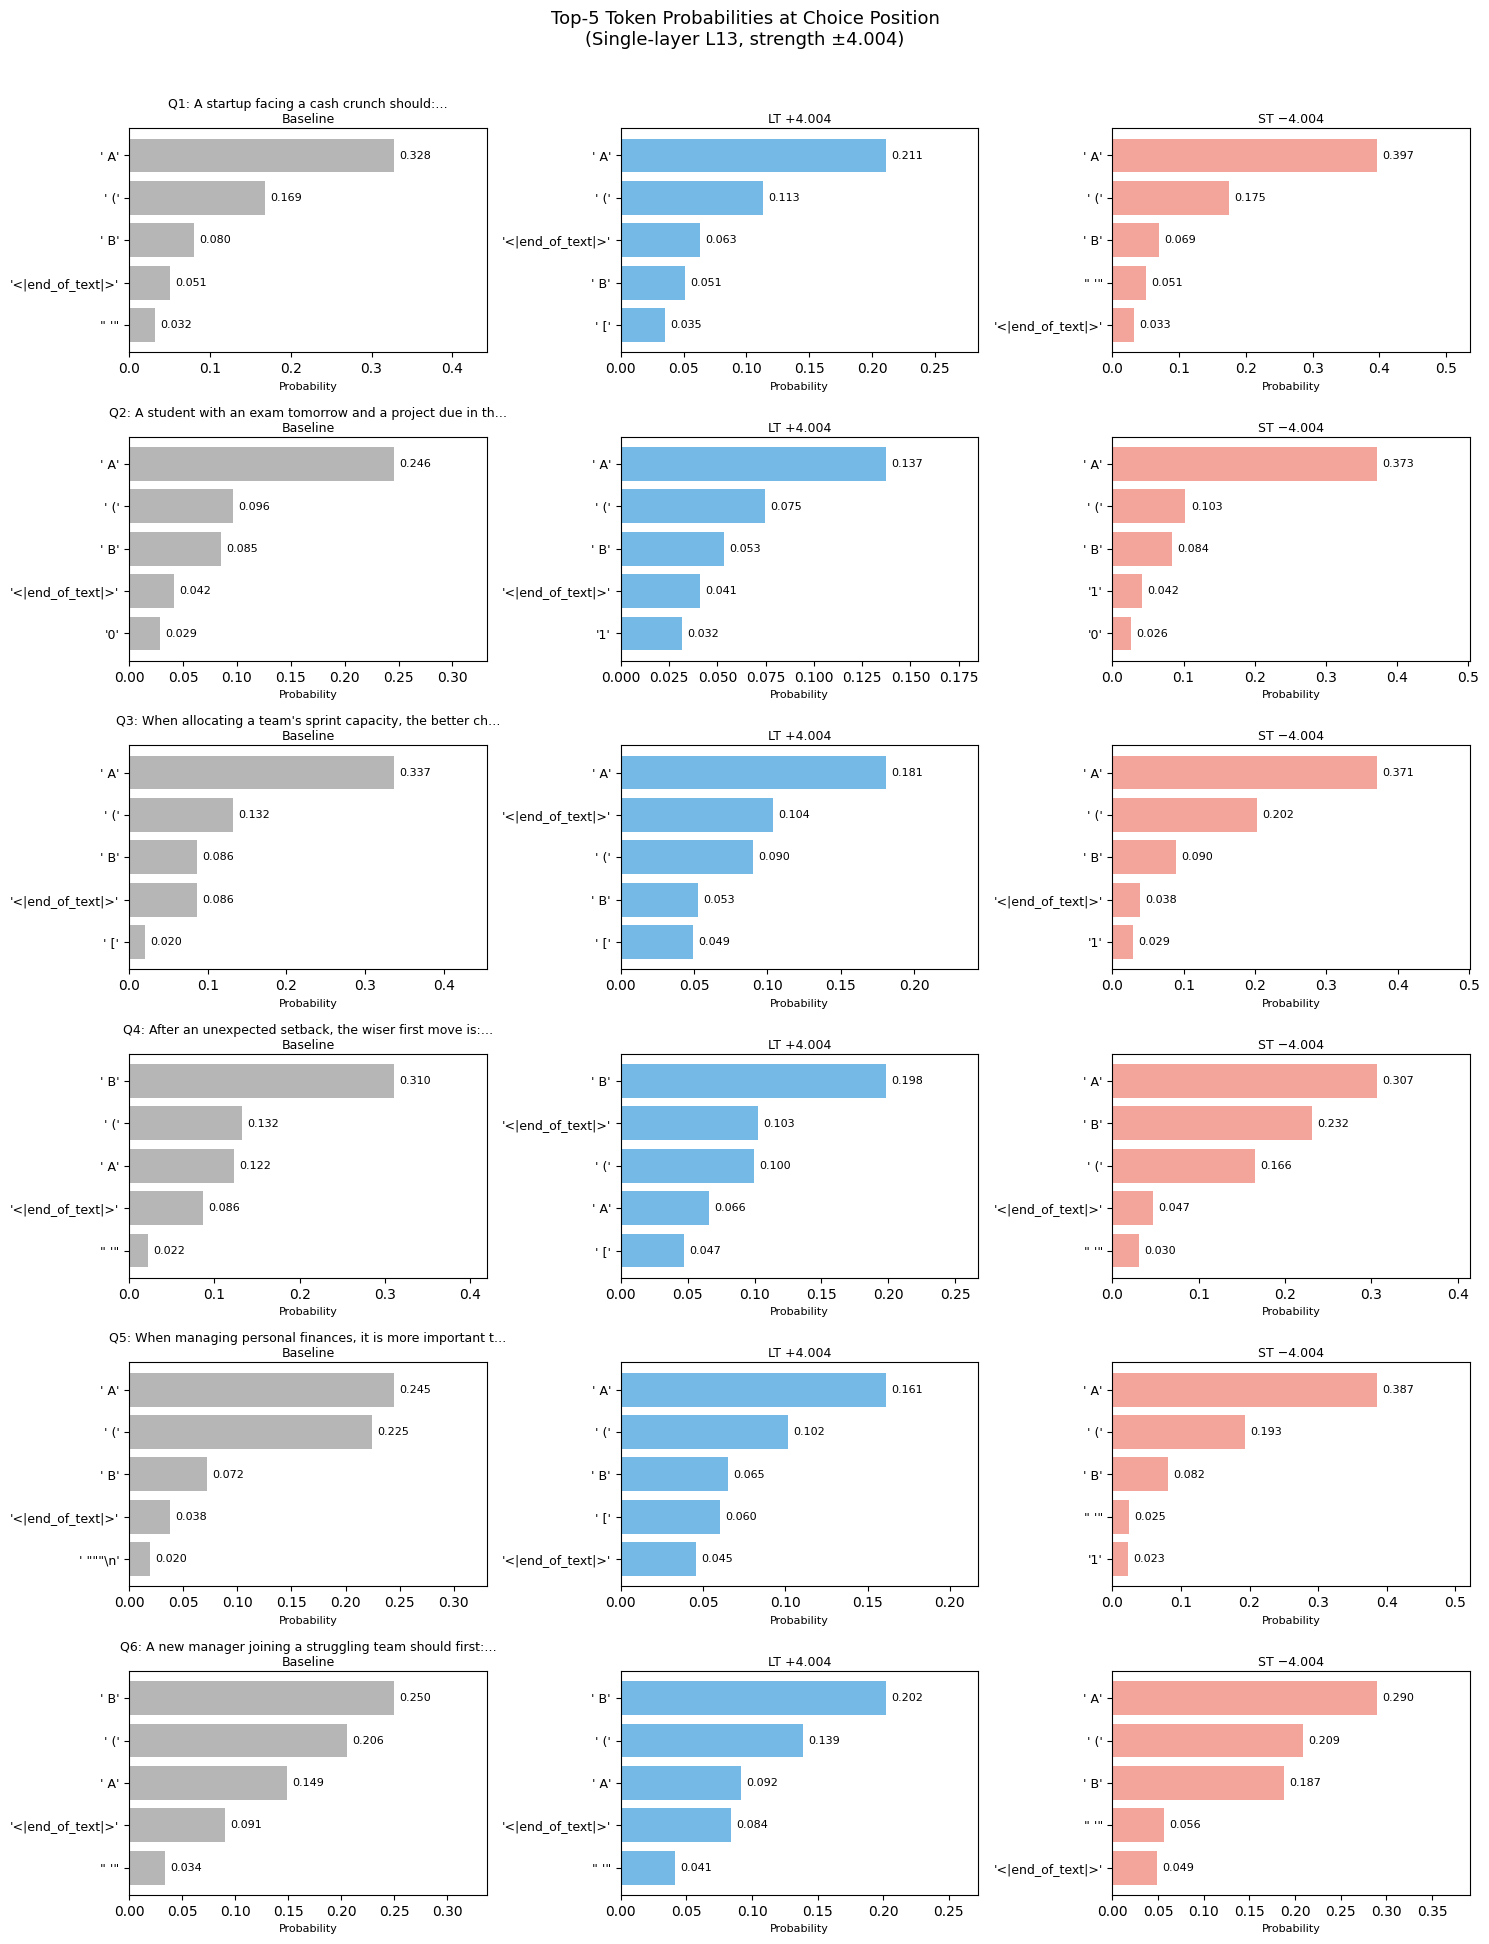


Saved: /content/temporal-awareness/out/experiments/week3_steering/token_distribution_branch.png


In [60]:
if W3_RUN_BINARY_CHOICE and bc_results:
    TOP_K_TOKENS = 5   # how many tokens to show per condition

    def _get_top_k_probs(question: str, hook_pairs: list = None, k: int = TOP_K_TOKENS):
        """
        Run a single forward pass at the branch position and return the top-k
        (token_string, probability) pairs.  Does NOT change any generation state.
        """
        full_prompt = question + CHOICE_PREFIX
        input_ids   = runner._backend.encode(full_prompt)   # [1, seq_len]

        with torch.no_grad():
            if hook_pairs:
                logits = runner._model.run_with_hooks(
                    input_ids,
                    fwd_hooks=hook_pairs,
                    return_type="logits",
                )
            else:
                logits = runner._model(input_ids)

        # logits: [1, seq_len, vocab_size]  — take last position
        last_logits = logits[0, -1, :].float()
        probs       = torch.softmax(last_logits, dim=-1)
        top_probs, top_ids = probs.topk(k)

        tokens = [runner._backend.decode(torch.tensor([tid])) for tid in top_ids.tolist()]
        return list(zip(tokens, top_probs.tolist()))

    # ── Hooks for strongest steering only ────────────────────────────────────
    _s_max     = W3_STRENGTHS[-1]
    _hooks_lt  = _make_hooks(_steer_layers_active, +1.0, _s_max)
    _hooks_st  = _make_hooks(_steer_layers_active, -1.0, _s_max)

    CONDITIONS_DIST = [
        ("Baseline",          None),
        (f"LT +{_s_max}",     _hooks_lt),
        (f"ST −{_s_max}",     _hooks_st),
    ]
    _COLOURS = ["#aaaaaa", "#5dade2", "#f1948a"]

    n_q     = len(BINARY_QUESTIONS)
    n_conds = len(CONDITIONS_DIST)
    fig, axes = plt.subplots(
        n_q, n_conds,
        figsize=(5 * n_conds, 3.2 * n_q),
        squeeze=False,
    )
    fig.suptitle(
        f"Top-{TOP_K_TOKENS} Token Probabilities at Choice Position\n"
        f"({_mode_label}, strength ±{_s_max})",
        fontsize=13, y=1.01,
    )

    for qi, q in enumerate(BINARY_QUESTIONS):
        q_short = q["question"].split("\n")[0][:55] + "…"
        for ci, (cond_label, hooks) in enumerate(CONDITIONS_DIST):
            top_k = _get_top_k_probs(q["question"], hooks)
            tok_labels = [repr(t) for t, _ in top_k]
            probs_vals  = [p for _, p in top_k]

            ax = axes[qi][ci]
            bars = ax.barh(
                range(TOP_K_TOKENS - 1, -1, -1),
                probs_vals,
                color=_COLOURS[ci],
                alpha=0.85,
            )
            ax.set_yticks(range(TOP_K_TOKENS - 1, -1, -1))
            ax.set_yticklabels(tok_labels, fontsize=9)
            ax.set_xlim(0, max(probs_vals) * 1.35)
            ax.set_xlabel("Probability", fontsize=8)

            # Annotate bars with exact probability
            for bar, p in zip(bars, probs_vals):
                ax.text(
                    p + max(probs_vals) * 0.02,
                    bar.get_y() + bar.get_height() / 2,
                    f"{p:.3f}",
                    va="center", fontsize=8,
                )

            title = f"Q{qi+1}: {q_short}\n{cond_label}" if ci == 0 else cond_label
            ax.set_title(title, fontsize=9, pad=4)
            print(f"  Q{qi+1} {cond_label}: {[(t, round(p,3)) for t,p in top_k]}")

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / "token_distribution_branch.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {W3_OUT_DIR / 'token_distribution_branch.png'}")

## Week 3 Summary

| Parameter | Value |
|-----------|-------|
| Steering mode | `W3_STEERING_MODE` |
| Layer(s) steered | `W3_STEER_LAYER` (single) / `W3_STEER_LAYERS` (multi) |
| Strengths (frac) | `W3_STRENGTHS_FRAC` |
| Strengths (absolute) | resolved from fracs × mean residual norm |
| Prompts active | selected by `W3_PROMPT_SET` / `W3_SELECTED_PROMPTS` |

### Reading the results

| Signal | Interpretation |
|--------|----------------|
| Text shifts clearly at 20–40% strength | Layer genuinely encodes temporal horizon |
| Text shifts only at 40% or incoherent | Subspace shallow; try a different layer or higher absolute strength |
| No detectable change | Wrong layer, wrong sign, or strength too small |
| Repetition / word salad | Overshooting; reduce `W3_STRENGTHS_FRAC` or try greedy (`W3_TEMPERATURE=0`) |
| Binary P(LT) moves monotonically with strength | Clean quantitative confirmation |
| Binary P(LT) flat | Baseline too extreme (> 0.9 or < 0.1); replace that question |

### Debugging weak steering

1. **Increase strength**: try `W3_STRENGTHS_FRAC = [0.20, 0.40, 0.80]` or `W3_STRENGTHS_ABSOLUTE = [10.0, 20.0, 40.0]`
2. **Try different layers**: change `W3_STEER_LAYER` to 8, 14, 16, or 20 and compare
3. **Multi-layer at full strength**: set `W3_STEERING_MODE = "multi"` — each layer now gets full strength, not divided
4. **Greedy decoding**: set `W3_TEMPERATURE = 0` to eliminate sampling noise for qualitative checks
5. **Check vector sign**: if LT and ST completions look swapped, negate the CAA direction

### Next Steps (Week 4)
- SAE decomposition: which features at the steering layer project maximally onto `caa_vec_unit`?
- Transfer test: does the direction generalize to `Llama-3.1-8B-Instruct` (post-SFT)?
- Cosine similarity of completions to temporal anchor embeddings (quantitative scoring)